In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.signal import welch, detrend

In [6]:
data_dir = "/Users/zoecas/Documents/data/"
ds = xr.open_dataset(data_dir+"SWOT_L2_LR_SSH_Basic_045_216_20260131T225821_20260131T234949_PID0_01.nc")
ds

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-02-02T16:31:42Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       58.654631510607544
    ssha_variance:                                 2.220821713141298
    references:                                    V1.4.1
    equator_longitude:                             -83.03

In [7]:
ssh_var = "ssh_karin"

# SWOT effective posting
DX_KM = 2.0
DY_KM = 2.0

# Fu & Smith style averaging adapted for SWOT
SEGMENT_LENGTH_KM = 256.0

# minimum valid fraction for keeping a profile
MIN_VALID_FRAC = 0.90

In [8]:
ds = ds.sel(num_lines=slice(4600,7600))
ssh = (ds[ssh_var]+ds["height_cor_xover"]).values

In [9]:
ssh

array([[   nan,    nan, 9.6659, ..., 8.0142,    nan,    nan],
       [   nan,    nan, 9.643 , ..., 7.9858,    nan,    nan],
       [   nan,    nan, 9.6192, ..., 7.9579,    nan,    nan],
       ...,
       [   nan,    nan,    nan, ...,    nan,    nan,    nan],
       [   nan,    nan,    nan, ...,    nan,    nan,    nan],
       [   nan,    nan,    nan, ...,    nan,    nan,    nan]],
      shape=(3000, 69))

In [10]:
valid_frac = np.mean(np.isfinite(ssh),axis=0)
good_cols = np.where(valid_frac > 0.5)[0]

breaks = np.where(np.diff(good_cols) > 1)[0]
if len(breaks) == 0:
    raise RuntimeError("Could not identify SWOT nadir gap.")

In [11]:
left_cols = good_cols[:breaks[0]+1]
right_cols = good_cols[breaks[0]+1:]

ssh_left = ssh[:, left_cols]
ssh_right = ssh[:, right_cols]

print("Left swath:", ssh_left.shape)
print("Right swath:", ssh_right.shape)


Left swath: (3000, 31)
Right swath: (3000, 31)


In [18]:
def fill_small_gaps(arr):
    da = xr.DataArray(arr,dims=["along","cross"])

    da = da.interpolate_na(dim="along",method="linear")#,max_gap={'along':3})

    da = da.interpolate_na(dim="cross",method="linear")#,max_gap={'along':3})

    return da.values

def along_track_spectrum(ssh_side,dx=2.0,segment_length=256.0):
    ssh_side = fill_small_gaps(ssh_side)
    nperseg = int(segment_length/dx)

    all_spectra = []
    for j in range(ssh_side.shape[1]):
        profile = ssh_side[:,j]
        valid_frac = (np.sum(np.isfinite(profile)) / len(profile))

        if valid_frac < MIN_VALID_FRAC:
            continue

        profile = np.where(np.isfinite(profile),profile,np.nanmean(profile))

       # profile = detrend(profile,type="linear")
        kx, P = welch(profile,fs=1.0/dx,window="hann",nperseg=nperseg,noverlap=nperseg//2,scaling="density")

        all_spectra.append(P)

    all_spectra = np.asarray(all_spectra)

    Ealong = np.nanmean(all_spectra,axis=0)

    return kx, Ealong
def cross_track_spectrum(ssh_side,dy=2.0):
    ssh_side = fill_small_gaps(ssh_side)
    ncross = ssh_side.shape[1]
    window = np.hanning(ncross)
    
    all_spectra = []
    for i in range(ssh_side.shape[0]):

        profile = ssh_side[i,:]
        valid_frac = (np.sum(np.isfinite(profile)) / len(profile))

        if valid_frac < MIN_VALID_FRAC:
            continue

        profile = np.where(np.isfinite(profile),profile,np.nanmean(profile))
        profile = detrend(profile,type="linear")
        profile = profile * window

        F = np.fft.rfft(profile)
        P = np.abs(F)**2
        all_spectra.append(P)
    all_spectra = np.asarray(all_spectra)
    Ecross = np.nanmean(all_spectra,axis=0)

    ky = np.fft.rfftfreq(ncross,d=dy)

    return ky, Ecross

In [17]:
ssh_left.shape

(3000, 31)

In [19]:
#Left
kx_L, Ealong_L = along_track_spectrum(ssh_left,dx=DX_KM,segment_length=SEGMENT_LENGTH_KM)
ky_L, Ecross_L = cross_track_spectrum(ssh_left,dy=DY_KM)

#Right
kx_R, Ealong_R = along_track_spectrum(ssh_right,dx=DX_KM,segment_length=SEGMENT_LENGTH_KM)
ky_R, Ecross_R = cross_track_spectrum(ssh_right,dy=DY_KM)

In [20]:
E_along = (Ealong_L +Ealong_R)/2.0

E_cross = (Ecross_L +Ecross_R)/2.0

kx = kx_L
ky = ky_L

In [21]:
from scipy.interpolate import interp1d
interp = interp1d(ky,E_cross,bounds_error=False,fill_value=np.nan)
E_cross_interp = interp(kx)
anisotropy = (E_along / E_cross_interp)


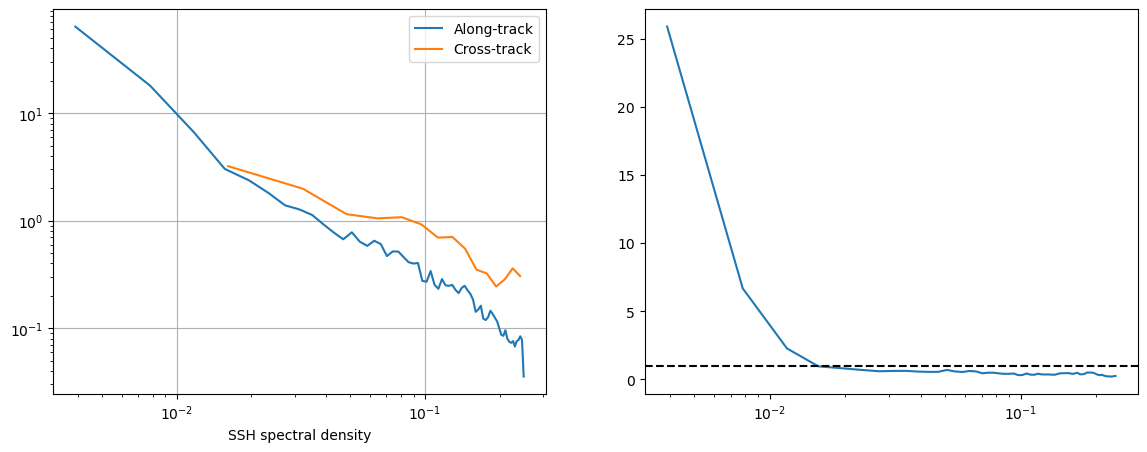

In [22]:
fig,axs = plt.subplots(1,2,figsize=(14,5))
ax=axs[0]
ax.loglog(kx[1:],E_along[1:],label="Along-track")
ax.loglog(ky[1:],E_cross[1:],label="Cross-track")
ax.set_xlabel('Wavenumber');ax.set_xlabel('SSH spectral density');
ax.legend();ax.grid();
ax=axs[1]
ax.semilogx(kx[1:],anisotropy[1:]);
ax.axhline(1,c='k',ls='--')